# Progetto: Riconoscimento di attività umane tramite segnali inerziali

1. Caricamento e Analisi della "Fisica" dei Dati

Forma del train: (50000, 32, 32, 3)
Esempio di un pixel (RGB): [59 62 63]


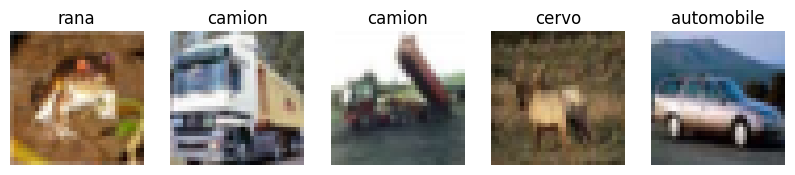

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from keras.utils import to_categorical

# Carichiamo il dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Definiamo le etichette reali
class_names = ['aereo', 'automobile', 'uccello', 'gatto', 'cervo', 
               'cane', 'rana', 'cavallo', 'nave', 'camion']

print(f"Forma del train: {X_train.shape}") # (50000, 32, 32, 3)
print(f"Esempio di un pixel (RGB): {X_train[0,0,0]}") 

# Visualizziamo una piccola galleria
plt.figure(figsize=(10,3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

Perché lo facciamo? Prima di elaborare, dobbiamo capire il "tensore" di input. Qui ogni immagine è una matrice $32 \times 32$ con 3 livelli di profondità. 

### 2. Preprocessing (Normalizzazione)
Applichiamo la normalizzazione e il One-Hot Encoding 

In [3]:
# 1. Normalizzazione: portiamo i valori dei pixel da [0, 255] a [0, 1]
# Logica: Le reti neurali sono sensibili alla scala. Gradienti più stabili.
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 2. One-Hot Encoding
# Logica: Le classi non hanno un ordine numerico (un cane non è "maggiore" di un aereo)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

### 3. Costruzione del Modello (CNN con Dropout)

In [4]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential([
    Input(shape=(32, 32, 3)),
    
    # Primo blocco: Filtri per catturare pattern elementari (bordi)
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    # Secondo blocco: Più filtri per pattern complessi (forme)
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    # Terzo blocco per profondità
    Conv2D(64, (3, 3), activation='relu'),
    
    Flatten(),
    Dense(64, activation='relu'),
    
    # Uso del Dropout (come nel tuo file) per prevenire l'overfitting fisico
    Dropout(0.5), 
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,490 (798.79 KB)

 Trainable params: 204,490 (798.79 KB)

 Non-trainable params: 0 (0.00 B)

Perché questa struttura? Usiamo il padding='same' per non perdere informazioni ai bordi dell'immagine durante la convoluzione

### 4. Compilazione e Callbacks (Controllo del Processo)

In [5]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Implementiamo i tuoi "guardiani" dell'addestramento
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

# Addestramento
history = model.fit(X_train, y_train_cat, 
                    epochs=20, 
                    batch_size=64, 
                    validation_split=0.2, 
                    callbacks=[early_stop, reduce_lr])

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 70ms/step - accuracy: 0.3534 - loss: 1.7545 - val_accuracy: 0.5121 - val_loss: 1.3764 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 0.5033 - loss: 1.3909 - val_accuracy: 0.5600 - val_loss: 1.2599 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.5630 - loss: 1.2394 - val_accuracy: 0.6340 - val_loss: 1.0608 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.6068 - loss: 1.1254 - val_accuracy: 0.6551 - val_loss: 0.9759 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.6314 - loss: 1.0505 - val_accuracy: 0.6788 - val_loss: 0.9249 - learning_rate: 0.0010
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.6583 - loss: 0.9813 - val_accuracy: 0.6852 - val_loss: 0.8994 - learning_rate: 0.0010
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - accuracy: 0.6757 - l

Perché i Callbacks? In fisica, se un esperimento smette di dare nuovi risultati (la loss non scende), è inutile continuare (Early Stopping). Se oscilliamo attorno al minimo, dobbiamo ridurre la "spinta" (Learning Rate).

### 5. Analisi dei Risultati (Il "Laboratorio")

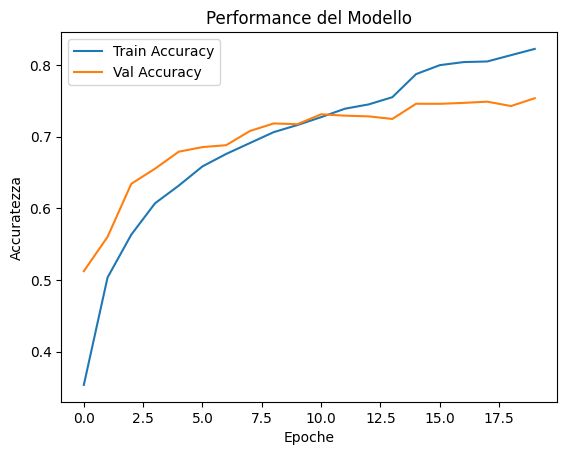

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7404 - loss: 0.7942
Accuratezza finale sul Test Set: 0.7404


In [6]:
# Plot dell'accuratezza
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Performance del Modello')
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')
plt.legend()
plt.show()

# Valutazione finale sul test set (dati mai visti)
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print(f"Accuratezza finale sul Test Set: {test_acc:.4f}")